#INFORMACIÓN GENERAL

UNIVERSIDAD NACIONAL DE SAN ANTONIO ABAD DEL CUSCO  
INGENIERÍA INFORMÁTICA Y DE SISTEMAS  
APRENDIZAJE NO SUPERVISADO  

# Preprocesamiento de Datos en Machine Learning


## 1. Contexto

Una empresa quiere predecir el abandono de clientes para priorizar campañas de retención.

Se cuenta con un dataset sintético que emula datos reales y contiene imperfecciones típicas (faltantes, outliers, duplicados y desbalance de clases).

**Datos disponibles**

Conjunto de registros de clientes con las siguientes variables:

*   edad (numérico): edad del cliente (años).

*   ingreso (numérico): ingreso anual estimado (sesgado, con posibles outliers).

*   canal (categórico): canal de adquisición (web, store, phone).

*   ciudad (categórico): ciudad principal (Cusco, Lima, Arequipa).

*   fecha_alta (fecha): fecha de alta del cliente.

*   abandono (binario; target): 1 si abandonó, 0 si se retuvo.

**Objetivo**

Desarrollar un pipeline de preprocesamiento que deje los datos listos para modelar y entrenar un modelo base de clasificación del abandono, reportando métricas y hallazgos clave.

##Marco conceptual

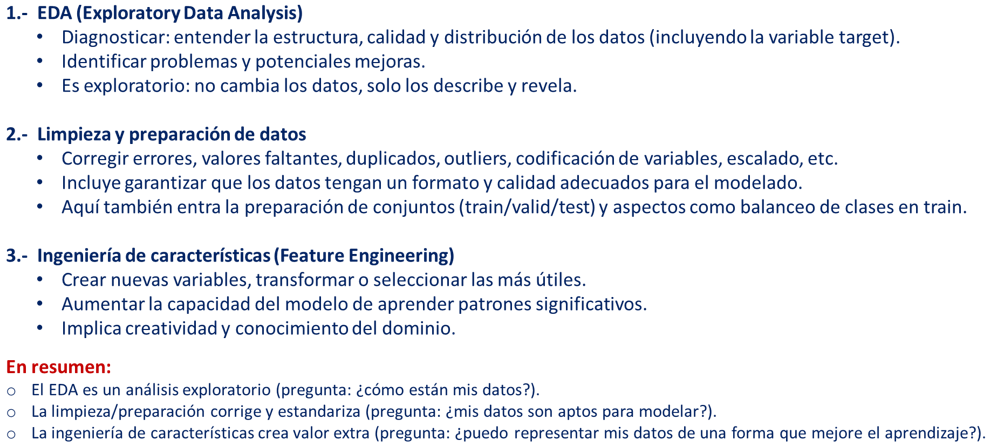

**Conceptos considerados en cada fase**

1. **EDA – Exploratory Data Analysis**  
   - Estructura y tipos  
   - Valores faltantes  
   - Distribuciones y estadísticas básicas  
   - Outliers  
   - Relaciones entre variables  
   - Análisis del target  
   - Patrones temporales  
2. **Limpieza / Preparación**  
   - Duplicados e inconsistencias  
   - Conversión de tipos  
   - Imputación de valores faltantes  
   - Tratamiento de outliers  
   - Escalado / normalización  
   - Codificación de categóricas  
   - División Train/Valid/Test (sin fuga de datos)  
3. **Ingeniería de características**  
   - Derivadas de fecha/tiempo  
   - Transformaciones y binning  
   - Interacciones y cruces  
   - Codificación avanzada (target encoding – precauciones)  
   - Reducción de dimensionalidad (PCA)  
   - Pipeline integrado con `ColumnTransformer` + evaluación  
   - Balanceo - SMOTE (sobremuestreo de la clase minoritaria)

##Configuración


###Instalación de librerías

In [ ]:
# Importar librerías
import numpy as np  # Operaciones numéricas eficientes y arrays multidimensionales
import pandas as pd  # Manipulación y análisis de datos estructurados (DataFrames, Series)
import matplotlib.pyplot as plt  # Visualización de datos y creación de gráficos

from datetime import datetime, timedelta  # Manipulación de fechas y tiempos

from sklearn.model_selection import train_test_split  # División de datos en conjuntos de entrenamiento y prueba
from sklearn.preprocessing import OneHotEncoder, StandardScaler, MinMaxScaler, RobustScaler, FunctionTransformer  # Preprocesamiento y transformación de características
from sklearn.compose import ColumnTransformer  # Transformación de columnas específicas en pipelines
from sklearn.pipeline import Pipeline  # Creación de flujos de procesamiento de datos secuenciales
from sklearn.linear_model import LogisticRegression  # Modelo de regresión logística para clasificación
from sklearn.metrics import classification_report, roc_auc_score, roc_curve  # Métricas de evaluación de modelos de clasificación
from sklearn.impute import SimpleImputer  # Imputación de valores faltantes en los datos



In [ ]:
# semilla para garantizar reproductibilidad de resultados
np.random.seed(42)

### Generación de data set

Se generará un dataset **sintético** con problemas intencionales (faltantes, outliers y duplicados) para ilustrar el preprocesamiento.


In [ ]:
# Generación de datos sintéticos
n = 1500  # cantidad de datos
edad = np.random.normal(38, 10, n).round(0)              # Distribución normal (μ=38, σ=10)
ingreso = np.random.lognormal(mean=9.5, sigma=0.55, size=n)  # Distribución log-normal (sesgada positivamente)
canal = np.random.choice(['web', 'store', 'phone'], size=n, p=[0.6, 0.3, 0.1])
ciudad = np.random.choice(['Cusco', 'Lima', 'Arequipa'], size=n, p=[0.2, 0.6, 0.2])
start = datetime(2019, 1, 1)
fecha_altas = [start + timedelta(days=int(x)) for x in np.random.randint(0, 2400, n)]

# Target binario desbalanceado: ~15% positivos
abandono = (np.random.rand(n) < 0.15).astype(int)

# creación del dataframe
df = pd.DataFrame({
    'edad': edad,
    'ingreso': ingreso,
    'canal': canal,
    'ciudad': ciudad,
    'fecha_alta': fecha_altas,
    'abandono': abandono
})

# Problemas intencionales
df.loc[np.random.choice(df.index, 60, replace=False), 'edad'] = np.nan      # 60 NaN aleatorios en edad
df.loc[np.random.choice(df.index, 40, replace=False), 'canal'] = None        # 40 NaN aleatorios en canal
df.loc[np.random.choice(df.index, 30, replace=False), 'ingreso'] *= 8        # 30 outliers extremos en ingreso
df = pd.concat([df, df.iloc[[5]]], ignore_index=True)                        # Duplicado intencional

# visualizar primeros datos
df.head()


,edad,ingreso,canal,ciudad,fecha_alta,abandono
0,43.0,20498.327817,store,Lima,2024-01-08,0
1,37.0,9865.981000,phone,Arequipa,2021-09-18,0
2,44.0,8518.457971,web,Lima,2024-11-16,0
3,53.0,13334.954819,phone,Lima,2025-06-22,0
4,36.0,12165.975701,web,Lima,2024-12-10,0


<a id="eda"></a>

## 2. EDA – Exploratory Data Analysis

**Objetivo:** diagnosticar estructura, calidad y patrones. Aún **no modificamos** los datos; solo observamos.


### 2.1 Estructura y tipos <a id="eda-struct"></a>

In [ ]:
display(df.head())
print("\nDimensiones:", df.shape)
print("\nInformación general:")
print(df.info())

,edad,ingreso,canal,ciudad,fecha_alta,abandono
0,43.0,20498.327817,store,Lima,2024-01-08,0
1,37.0,9865.981000,phone,Arequipa,2021-09-18,0
2,44.0,8518.457971,web,Lima,2024-11-16,0
3,53.0,13334.954819,phone,Lima,2025-06-22,0
4,36.0,12165.975701,web,Lima,2024-12-10,0



Dimensiones: (1501, 6)

Información general:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1501 entries, 0 to 1500
Data columns (total 6 columns):
 #   Column      Non-Null Count  Dtype         
---  ------      --------------  -----         
 0   edad        1441 non-null   float64       
 1   ingreso     1501 non-null   float64       
 2   canal       1461 non-null   object        
 3   ciudad      1501 non-null   object        
 4   fecha_alta  1501 non-null   datetime64[ns]
 5   abandono    1501 non-null   int64         
dtypes: datetime64[ns](1), float64(2), int64(1), object(2)
memory usage: 70.5+ KB
None


### 2.2 Valores faltantes <a id="eda-missing"></a>

,edad,canal,ingreso,ciudad,fecha_alta,abandono
n_missing,60,40,0,0,0,0


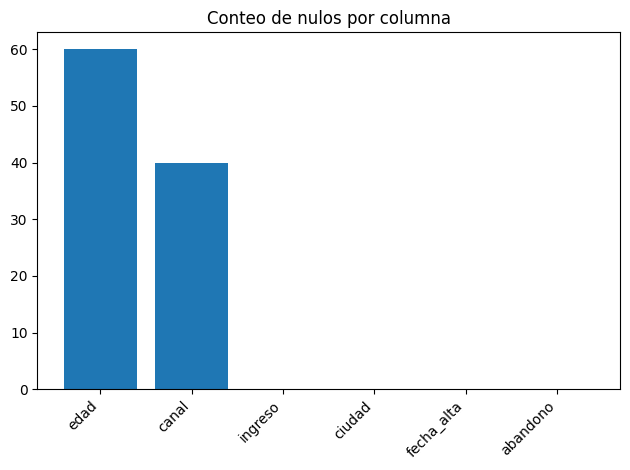

In [ ]:
# Determinar valores faltantes y contar valores nulos por columna
missing = df.isna().sum().sort_values(ascending=False)
display(missing.to_frame('n_missing').T)

# Gráfica del conteo de nulos por columna
plt.figure()
plt.bar(missing.index, missing.values)
plt.xticks(rotation=45, ha='right')
plt.title('Conteo de nulos por columna')
plt.tight_layout()
plt.show()


### 2.3 Distribuciones y estadísticas básicas <a id="eda-dists"></a>

               edad        ingreso canal ciudad  \
count   1441.000000    1501.000000  1461   1501   
unique          NaN            NaN     3      3   
top             NaN            NaN   web   Lima   
freq            NaN            NaN   907    888   
mean      38.514226   17886.646177   NaN    NaN   
min        6.000000    2538.346882   NaN    NaN   
25%       32.000000    9495.125313   NaN    NaN   
50%       39.000000   13504.647463   NaN    NaN   
75%       45.000000   19620.998644   NaN    NaN   
max       77.000000  283753.883099   NaN    NaN   
std        9.969187   20426.808097   NaN    NaN   

                           fecha_alta     abandono  
count                            1501  1501.000000  
unique                            NaN          NaN  
top                               NaN          NaN  
freq                              NaN          NaN  
mean    2022-03-26 00:40:17.588274688     0.156562  
min               2019-01-01 00:00:00     0.000000  
25%             

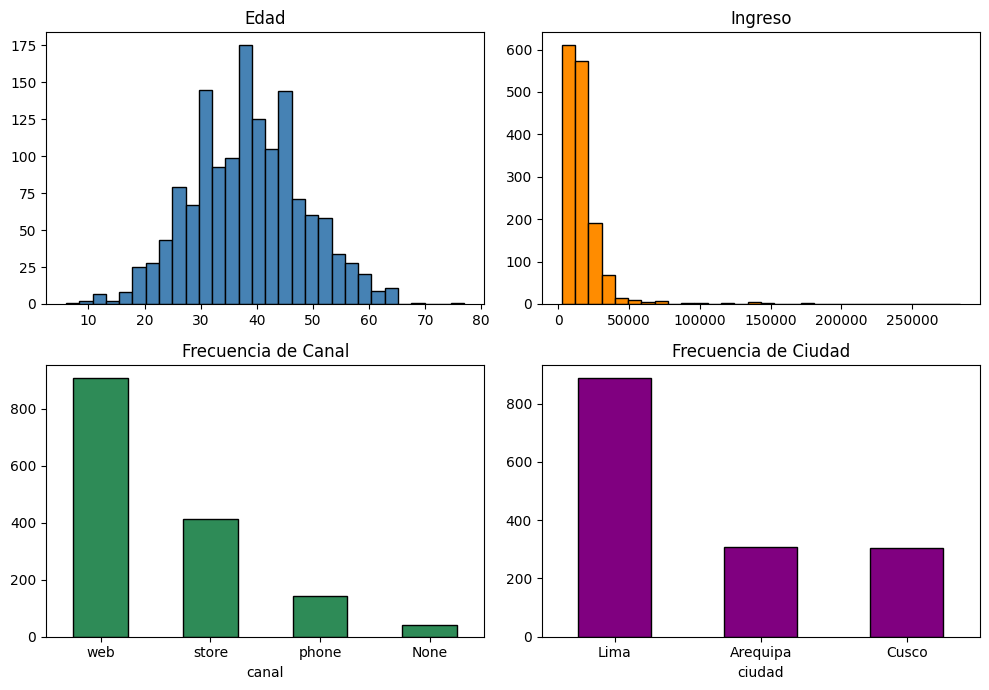

In [ ]:
# Distribuciones y estadísticas básicas
print(df.describe(include='all'))

# Histogramas
fig, axes = plt.subplots(2, 2, figsize=(10, 7))

# Histograma de Edad
axes[0, 0].hist(df['edad'].dropna(), bins=30, color='steelblue', edgecolor='black')
axes[0, 0].set_title('Edad')

# Histograma de Ingreso
axes[0, 1].hist(df['ingreso'].dropna(), bins=30, color='darkorange', edgecolor='black')
axes[0, 1].set_title('Ingreso')

# Frecuencia de Canal
df['canal'].value_counts(dropna=False).plot(kind='bar', ax=axes[1, 0], color='seagreen', edgecolor='black')
axes[1, 0].set_title('Frecuencia de Canal')
axes[1, 0].tick_params(axis='x', rotation=0)

# Frecuencia de Ciudad
df['ciudad'].value_counts().plot(kind='bar', ax=axes[1, 1], color='purple', edgecolor='black')
axes[1, 1].set_title('Frecuencia de Ciudad')
axes[1, 1].tick_params(axis='x', rotation=0)

plt.tight_layout()
plt.show()


### 2.4 Outliers <a id="eda-outliers"></a>

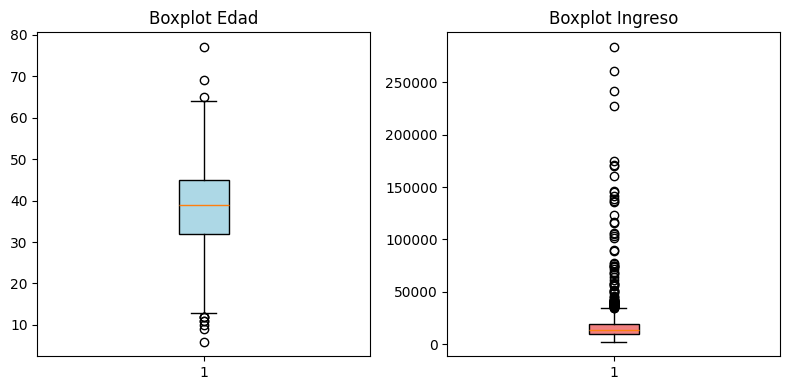

IQR ingreso -> lower=-5693.68, upper=34809.81
Posibles outliers (ingreso > upper): 86


In [ ]:
# Boxplots de edad e ingreso
fig, axes = plt.subplots(1, 2, figsize=(8, 4))

# Diagrama de caja de Edad
axes[0].boxplot(df['edad'].dropna(), patch_artist=True, boxprops=dict(facecolor='lightblue'))
axes[0].set_title('Boxplot Edad')

# Diagrama de caja de Ingreso
axes[1].boxplot(df['ingreso'].dropna(), patch_artist=True, boxprops=dict(facecolor='lightcoral'))
axes[1].set_title('Boxplot Ingreso')

plt.tight_layout()
plt.show()

# Cálculo de IQR y outliers en ingreso
q1 = df['ingreso'].quantile(0.25)
q3 = df['ingreso'].quantile(0.75)
iqr = q3 - q1
lower = q1 - 1.5 * iqr
upper = q3 + 1.5 * iqr

print(f'IQR ingreso -> lower={lower:.2f}, upper={upper:.2f}')
print('Posibles outliers (ingreso > upper):', int((df['ingreso'] > upper).sum()))


### 2.5 Relaciones entre variables <a id="eda-rel"></a>

,edad,ingreso,abandono
edad,1.000000,0.030217,0.013241
ingreso,0.030217,1.000000,0.029333
abandono,0.013241,0.029333,1.000000


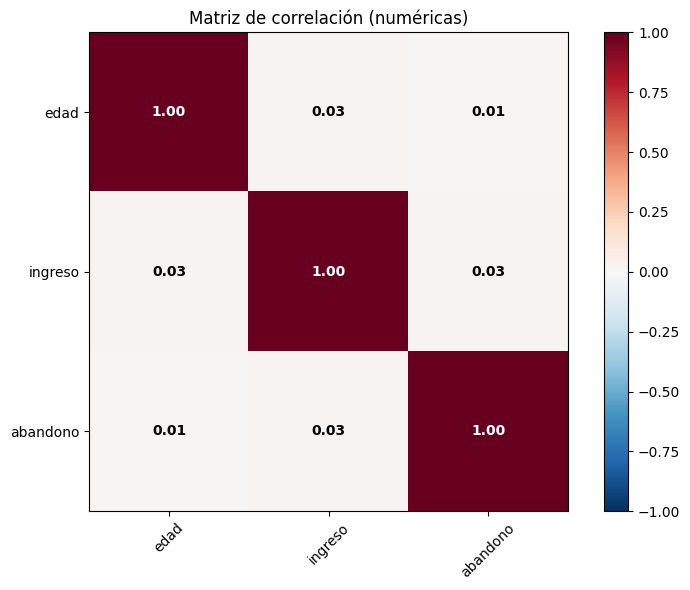

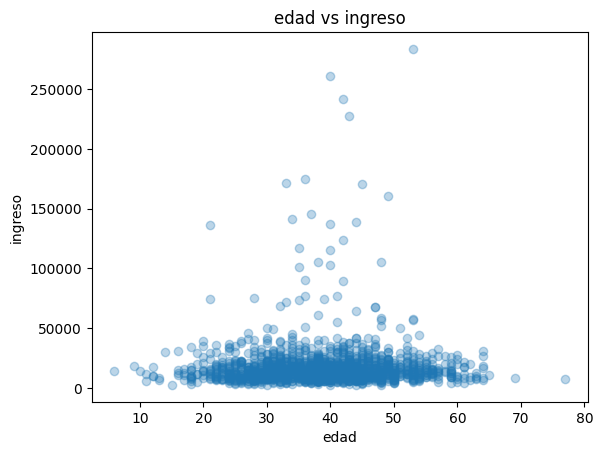

In [ ]:
# Determinar correlación entre variables numéricas
corr = df[['edad', 'ingreso', 'abandono']].corr()

display(corr)

# Matriz de correlación entre las variables numéricas edad, ingreso y abandono
# Coeficiente de correlación de Pearson
plt.figure(figsize=(8, 6))
im = plt.imshow(corr, vmin=-1, vmax=1, cmap='RdBu_r')

# Añadir los valores de correlación como texto en cada celda
for i in range(corr.shape[0]):
    for j in range(corr.shape[1]):
        plt.text(j, i, f'{corr.iloc[i, j]:.2f}',
                 ha='center', va='center',
                 color='white' if abs(corr.iloc[i, j]) > 0.5 else 'black',
                 fontweight='bold')

plt.xticks(range(corr.shape[1]), corr.columns, rotation=45)
plt.yticks(range(corr.shape[0]), corr.index)
plt.colorbar(im)
plt.title('Matriz de correlación (numéricas)')
plt.tight_layout()
plt.show()

# Diagrama de dispersión entre edad (eje X) e ingreso (eje Y)
plt.figure()
plt.scatter(df['edad'], df['ingreso'], alpha=0.3)
plt.xlabel('edad'); plt.ylabel('ingreso'); plt.title('edad vs ingreso')
plt.show()


### 2.6 Análisis del target <a id="eda-target"></a>

abandono
0    1266
1     235
Name: count, dtype: int64


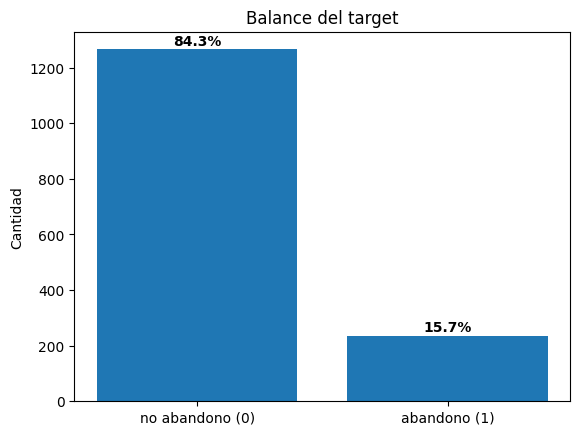

In [ ]:
# Explorar el balance de la variable objetivo (abandono)
tc = df['abandono'].value_counts().sort_index()

print(tc)

plt.figure()
bars = plt.bar(['no abandono (0)', 'abandono (1)'], tc.values)
plt.title('Balance del target')
plt.ylabel('Cantidad')

# Calcular porcentajes y añadirlos sobre las barras
total = sum(tc.values)
for i, bar in enumerate(bars):
    height = bar.get_height()
    percentage = (height / total) * 100
    plt.text(bar.get_x() + bar.get_width()/2., height + 5,
             f'{percentage:.1f}%',
             ha='center', va='bottom',
             fontweight='bold')

plt.show()


### 2.7 Patrones temporales <a id="eda-time"></a>

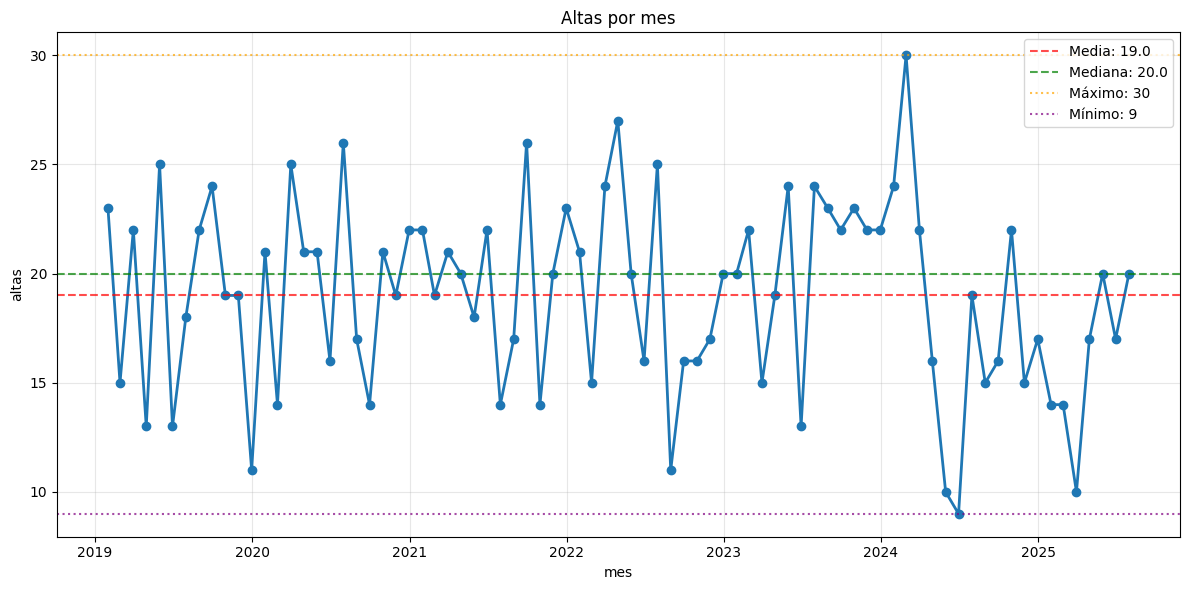

In [ ]:
# crear serie de pandas: número de altas por mes
series = (df.set_index('fecha_alta')
            .resample('ME').size())

plt.figure(figsize=(12, 6))
plt.plot(series.index, series.values, marker='o', linestyle='-', linewidth=2)
plt.title('Altas por mes'); plt.xlabel('mes'); plt.ylabel('altas')

# Líneas horizontales de referencia
plt.axhline(y=series.mean(), color='r', linestyle='--', alpha=0.7, label=f'Media: {series.mean():.1f}')
plt.axhline(y=series.median(), color='g', linestyle='--', alpha=0.7, label=f'Mediana: {series.median():.1f}')
plt.axhline(y=series.max(), color='orange', linestyle=':', alpha=0.7, label=f'Máximo: {series.max():.0f}')
plt.axhline(y=series.min(), color='purple', linestyle=':', alpha=0.7, label=f'Mínimo: {series.min():.0f}')

plt.grid(True, alpha=0.3)
plt.legend()
plt.tight_layout()
plt.show()


<a id="prep"></a>

## 3. Limpieza / Preparación

**Objetivo:** corregir problemas (nulos, outliers, tipos), normalizar y **dejar los datos listos** para el modelado, evitando *data leakedad*.


### 3.1 Duplicados e inconsistencias <a id="prep-dups"></a>

In [ ]:
# eliminación de duplicados
before = len(df)
df = df.drop_duplicates().reset_index(drop=True)

print('Duplicados eliminados:', before - len(df))


Duplicados eliminados: 1


### 3.2 Conversión de tipos <a id="prep-types"></a>

In [ ]:
# información antes de conversión (poner atención a atributos categóricos)
print("\nInformación general antes de la conversión:")
print(df.info())


Información general antes de la conversión:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1500 entries, 0 to 1499
Data columns (total 6 columns):
 #   Column      Non-Null Count  Dtype         
---  ------      --------------  -----         
 0   edad        1440 non-null   float64       
 1   ingreso     1500 non-null   float64       
 2   canal       1460 non-null   object        
 3   ciudad      1500 non-null   object        
 4   fecha_alta  1500 non-null   datetime64[ns]
 5   abandono    1500 non-null   int64         
dtypes: datetime64[ns](1), float64(2), int64(1), object(2)
memory usage: 70.4+ KB
None


In [ ]:
# Convertir la columna a tipo datetime, forzando valores inválidos a NaT (Not a Time)
df['fecha_alta'] = pd.to_datetime(df['fecha_alta'], errors='coerce')

# Convertir a tipo category (para eficiencia de memoria y procesamiento)
df['canal']  = df['canal'].astype('category')
df['ciudad'] = df['ciudad'].astype('category')

# Mostrar información resumida del DataFrame
df.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1500 entries, 0 to 1499
Data columns (total 6 columns):
 #   Column      Non-Null Count  Dtype         
---  ------      --------------  -----         
 0   edad        1440 non-null   float64       
 1   ingreso     1500 non-null   float64       
 2   canal       1460 non-null   category      
 3   ciudad      1500 non-null   category      
 4   fecha_alta  1500 non-null   datetime64[ns]
 5   abandono    1500 non-null   int64         
dtypes: category(2), datetime64[ns](1), float64(2), int64(1)
memory usage: 50.2 KB


### 3.3 Imputación de valores faltantes

In [ ]:
print("=== ESTADÍSTICOS ANTES Y DESPUÉS DE LA IMPUTACIÓN ===\n")

# Estadísticos originales de edad
print("IMPACTO EN EDAD:")
print("Original - antes de imputación:")
print(f"  Valores nulos: {df['edad'].isnull().sum()}")
print(f"  Media: {df['edad'].mean():.2f}")
print(f"  Mediana: {df['edad'].median():.2f}")
print(f"  Desviación estándar: {df['edad'].std():.2f}")
print(f"  Mínimo: {df['edad'].min():.2f}")
print(f"  Máximo: {df['edad'].max():.2f}")

# Reemplazar los valores nulos con la mediana de la columna
df['edad_imp'] = df['edad'].fillna(df['edad'].median())

print("\nDespués de imputación (mediana):")
print(f"  Valores nulos: {df['edad_imp'].isnull().sum()}")
print(f"  Media: {df['edad_imp'].mean():.2f}")
print(f"  Mediana: {df['edad_imp'].median():.2f}")
print(f"  Desviación estándar: {df['edad_imp'].std():.2f}")
print(f"  Mínimo: {df['edad_imp'].min():.2f}")
print(f"  Máximo: {df['edad_imp'].max():.2f}")

print("\n" + "=" * 50 + "\n")

# Estadísticos originales de canal
print("IMPACTO EN CANAL:")
print("Original - antes de imputación:")
print(f"  Valores nulos: {df['canal'].isnull().sum()}")
print(f"  Valores únicos: {df['canal'].nunique()}")
print("  Distribución de categorías:")
print(df['canal'].value_counts(dropna=False))

# Reemplazar los nulos con la categoría más frecuente (moda)
moda_canal = df['canal'].mode(dropna=True)[0]
df['canal_imp'] = df['canal'].fillna(moda_canal).astype('category')

print("\nDespués de imputación (moda):")
print(f"  Valores nulos: {df['canal_imp'].isnull().sum()}")
print(f"  Valores únicos: {df['canal_imp'].nunique()}")
print("  Distribución de categorías:")
print(df['canal_imp'].value_counts())

print("\n" + "=" * 50 + "\n")

# Mostrar las primeras filas comparativas
print(" PRIMERAS FILAS COMPARATIVAS:")
display(df[['edad','edad_imp','canal','canal_imp']].head(10))

# Mostrar filas donde hubo imputación
print("\n FILAS CON IMPUTACIÓN (donde original era nulo):")
imputed_rows = df[df['edad'].isnull() | df['canal'].isnull()]
display(imputed_rows[['edad','edad_imp','canal','canal_imp']].head())


=== ESTADÍSTICOS ANTES Y DESPUÉS DE LA IMPUTACIÓN ===

IMPACTO EN EDAD:
Original - antes de imputación:
  Valores nulos: 60
  Media: 38.52
  Mediana: 39.00
  Desviación estándar: 9.97
  Mínimo: 6.00
  Máximo: 77.00

Después de imputación (mediana):
  Valores nulos: 0
  Media: 38.54
  Mediana: 39.00
  Desviación estándar: 9.77
  Mínimo: 6.00
  Máximo: 77.00


IMPACTO EN CANAL:
Original - antes de imputación:
  Valores nulos: 40
  Valores únicos: 3
  Distribución de categorías:
canal
web      906
store    411
phone    143
NaN       40
Name: count, dtype: int64

Después de imputación (moda):
  Valores nulos: 0
  Valores únicos: 3
  Distribución de categorías:
canal_imp
web      946
store    411
phone    143
Name: count, dtype: int64


 PRIMERAS FILAS COMPARATIVAS:


,edad,edad_imp,canal,canal_imp
0,43.0,43.0,store,store
1,37.0,37.0,phone,phone
2,44.0,44.0,web,web
3,53.0,53.0,phone,phone
4,36.0,36.0,web,web
5,36.0,36.0,web,web
6,54.0,54.0,NaN,web
7,46.0,46.0,web,web
8,33.0,33.0,store,store
9,43.0,43.0,web,web



 FILAS CON IMPUTACIÓN (donde original era nulo):


,edad,edad_imp,canal,canal_imp
6,54.0,54.0,NaN,web
10,NaN,39.0,web,web
32,38.0,38.0,NaN,web
40,45.0,45.0,NaN,web
47,49.0,49.0,NaN,web


> **Importante**: En un flujo productivo, nunca se debe imputar valores sobre todo el dataset simultáneamente debido al riesgo de data leakage (fuga de datos). Este problema ocurre cuando información del conjunto de prueba (TEST) o validación (VALID) se utiliza durante la fase de preprocesamiento, contaminando el proceso de entrenamiento.

La metodología correcta consiste en ajustar los imputadores utilizando exclusivamente los datos de entrenamiento (TRAIN) para calcular estadísticas como medianas, modas o medias. Luego, se debe aplicar ese mismo imputador ya ajustado para transformar tanto los datos de validación como de prueba. De esta manera, se garantiza que el modelo no tenga acceso anticipado a información futura y su evaluación sea realista y confiable.

Esto se resuelve de forma elegante con un **`ColumnTransformer` + `Pipeline`** (Se ilustra en la sección 4.6).

### 3.4 Tratamiento de outliers <a id="prep-outliers"></a>

**Winsorización** es el proceso de reducir el impacto de outliers extremos sin eliminarlos del dataset.  
**En que consiste:**  
*   Se calculan los percentiles 1 y 99 de los datos (ignorando NaN)  
*   Estos valores se usan como límites inferior y superior.  
*   Con ***np.clip(x, low, high)*** se “recorta” todos los valores que estén por debajo del percentil 1 (se reemplazan por el valor del percentil 1) y los que estén por encima del percentil 99 (se reemplazan por el valor del percentil 99).

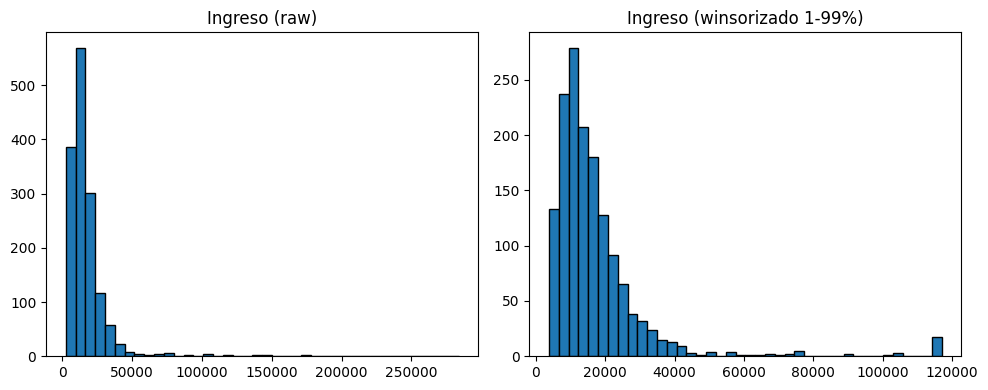

In [ ]:
def winsorize_1_99(x):
    # Aplica winsorización al 1%: reemplaza valores extremos inferior y superior (1% y 99%)
    # con los percentiles correspondientes para reducir el impacto de outliers
    lo = x.quantile(0.01)
    hi = x.quantile(0.99)
    return x.clip(lower=lo, upper=hi)

df['ingreso_win'] = winsorize_1_99(df['ingreso'])

# Mostrar histogramas lado a lado
fig, axes = plt.subplots(1, 2, figsize=(10, 4))

axes[0].hist(df['ingreso'], bins=40, edgecolor='black')
axes[0].set_title('Ingreso (raw)')

axes[1].hist(df['ingreso_win'], bins=40, edgecolor='black')
axes[1].set_title('Ingreso (winsorizado 1-99%)')

plt.tight_layout()
plt.show()


### 3.5 Escalado / normalización <a id="prep-scale"></a>

**Escalar (normalizar/estandarizar) variables numéricas**  

El escalado de datos numéricos consiste en transformar las variables a un rango o distribución comparable, evitando que diferencias en magnitud distorsionen el análisis o el aprendizaje automático; esto es necesario porque muchos algoritmos —como los basados en distancias (kNN, k-Means, SVM) o en gradientes (regresión logística, redes neuronales)— son sensibles a la escala de las variables, de modo que, sin escalado, aquellas con valores más grandes dominarían los cálculos y generarían modelos sesgados, menos estables o con convergencia más lenta.  

**Algunas técnicas de escalado**
*   *StandardScaler*: transforma cada variable para que tenga media 0 y desviación estándar 1.

*   *RobustScaler*: usa la mediana y el IQR (Q3–Q1) en lugar de media y desviación estándar, por lo que es más robusto frente a outliers.

*   *MinMaxScaler*: escala cada variable a un rango fijo, normalmente [0, 1] (puedes cambiarlo).

In [ ]:
# Definir técnicas de escalado
std_scaler  = StandardScaler()
rob_scaler  = RobustScaler()
mm_scaler   = MinMaxScaler()

# Escalar variables con valores muy dispares (edad imputada e ingreso winsorizado)
X_num = df[['edad_imp', 'ingreso_win']].to_numpy()

std_vals = std_scaler.fit_transform(X_num)
rob_vals = rob_scaler.fit_transform(X_num)
mm_vals  = mm_scaler.fit_transform(X_num)

# Mostrar valores originales
print('Valores originales (3 primeras filas)')
print(X_num[:3])
print()

# Mostrar resultados de valores escalados
print('StandardScaler (3 primeras filas):\n', std_vals[:3])
print('RobustScaler (3 primeras filas):\n', rob_vals[:3])
print('MinMaxScaler (3 primeras filas):\n', mm_vals[:3])


Valores originales (3 primeras filas)
[[   43.         20498.32781689]
 [   37.          9865.98100033]
 [   44.          8518.45797095]]

StandardScaler (3 primeras filas):
 [[ 0.45707008  0.20819368]
 [-0.15717969 -0.4830578 ]
 [ 0.55944504 -0.57066568]]
RobustScaler (3 primeras filas):
 [[ 0.32653061  0.68903842]
 [-0.16326531 -0.35914773]
 [ 0.40816327 -0.49199281]]
MinMaxScaler (3 primeras filas):
 [[0.52112676 0.14757911]
 [0.43661972 0.05373898]
 [0.53521127 0.04184586]]


### 3.6 Codificación de variables categóricas

La **codificación de variables categóricas** es el proceso de transformar variables que contienen categorías o etiquetas (texto o clases) en representaciones numéricas que los algoritmos de Machine Learning puedan procesar. Se hace porque la mayoría de los modelos matemáticos solo trabajan con números.  

Se codifican variables categóricas para que los algoritmos:  
*   Puedan utilizarlas en cálculos matemáticos, ya que los modelos no interpretan texto.  
*   Eviten sesgos artificiales: la elección del método de codificación (one-hot, ordinal, target encoding, etc.) depende del tipo de variable y del modelo; por ejemplo, no conviene asignar números arbitrarios (1,2,3) a categorías sin orden, porque el modelo podría “suponer” que hay una relación ordinal que no existe.  

In [ ]:
from sklearn.preprocessing import OneHotEncoder
import numpy as np
import pandas as pd

# Convertir variables categóricas (canal_imp y ciudad) a binarias usando One-Hot Encoding
ohe = OneHotEncoder(sparse_output=False, handle_unknown='ignore')
X_cat = ohe.fit_transform(df[['canal_imp', 'ciudad']])

print('Resultados de one hot encoding \n')

# Mostrar dimensiones
print(' Tamaño de la matriz transformada:', X_cat.shape)
print(f'   - Filas (muestras): {X_cat.shape[0]}')
print(f'   - Columnas (categorías binarias): {X_cat.shape[1]}')

# Mostrar nombres de las nuevas columnas
print('\n Nombres de las nuevas columnas:')
categorias = ohe.get_feature_names_out(['canal_imp', 'ciudad'])
for i, categoria in enumerate(categorias):
    print(f'   Columna {i}: {categoria}')

# Mostrar valores únicos originales y su transformación
print('\n Valores únicos originales:')
print('   - canal_imp:', df['canal_imp'].unique())
print('   - ciudad:', df['ciudad'].unique())

# Ejemplos de la transformación (primeras 5 filas)
ejemplo = pd.DataFrame(X_cat[:5], columns=categorias)
print('\n Ejemplos (primeras 5 filas transformadas):')
display(ejemplo)

# Información adicional
print('\n Información adicional:')
print(f'   - Se crearon {len(categorias)} columnas binarias')
print('   - handle_unknown="ignore": categorías nuevas en test se codifican como ceros')
print('   - Cada fila tendrá exactamente un 1 por variable original (suma=1 por grupo)')


Resultados de one hot encoding 

 Tamaño de la matriz transformada: (1500, 6)
   - Filas (muestras): 1500
   - Columnas (categorías binarias): 6

 Nombres de las nuevas columnas:
   Columna 0: canal_imp_phone
   Columna 1: canal_imp_store
   Columna 2: canal_imp_web
   Columna 3: ciudad_Arequipa
   Columna 4: ciudad_Cusco
   Columna 5: ciudad_Lima

 Valores únicos originales:
   - canal_imp: ['store', 'phone', 'web']
Categories (3, object): ['phone', 'store', 'web']
   - ciudad: ['Lima', 'Arequipa', 'Cusco']
Categories (3, object): ['Arequipa', 'Cusco', 'Lima']

 Ejemplos (primeras 5 filas transformadas):


,canal_imp_phone,canal_imp_store,canal_imp_web,ciudad_Arequipa,ciudad_Cusco,ciudad_Lima
0,0.0,1.0,0.0,0.0,0.0,1.0
1,1.0,0.0,0.0,1.0,0.0,0.0
2,0.0,0.0,1.0,0.0,0.0,1.0
3,1.0,0.0,0.0,0.0,0.0,1.0
4,0.0,0.0,1.0,0.0,0.0,1.0



 Información adicional:
   - Se crearon 6 columnas binarias
   - handle_unknown="ignore": categorías nuevas en test se codifican como ceros
   - Cada fila tendrá exactamente un 1 por variable original (suma=1 por grupo)


***Ejercicio:***  
Investigar otras técnicas de codificar variables categóricas, y escribirlas en esta celda.

In [ ]:
# Otras técnicas de codificación de variables categóricas
#
# 1) Label Encoding: asigna un número entero a cada categoría.
#    Útil para variables ORDINALES (ej. talla: S=0, M=1, L=2).
from sklearn.preprocessing import LabelEncoder
le = LabelEncoder()
ejemplo_label = le.fit_transform(df['ciudad'].astype(str))
print('Label Encoding ciudad (primeros 10):', ejemplo_label[:10])
print('Mapeo:', dict(zip(le.classes_, le.transform(le.classes_))))

# 2) Ordinal Encoding (sklearn): igual que label pero para múltiples columnas y permite definir el orden.
from sklearn.preprocessing import OrdinalEncoder
oe = OrdinalEncoder()
ej_ord = oe.fit_transform(df[['ciudad']].astype(str))
print('\nOrdinal Encoding (primeros 5):', ej_ord[:5].ravel())

# 3) Frequency / Count Encoding: reemplaza cada categoría por su frecuencia.
freq_map = df['canal_imp'].value_counts(normalize=True).to_dict()
ejemplo_freq = df['canal_imp'].map(freq_map)
print('\nFrequency Encoding canal_imp (primeros 5):')
print(ejemplo_freq.head())

# 4) Target/Mean Encoding: media de la variable objetivo por categoría (riesgo de leakage; usar CV).
te_map = df.groupby('canal_imp', observed=True)['abandono'].mean()
print('\nTarget Encoding canal_imp -> media de abandono:')
print(te_map)

# 5) Binary Encoding y Hashing Encoding (categóricas de alta cardinalidad):
#    requieren la librería `category_encoders`.
#    - BinaryEncoder: representa el índice de la categoría en binario => log2(N) columnas.
#    - HashingEncoder: usa una función hash; útil cuando aparecen categorías nuevas en producción.
print("\nOtras opciones (requieren 'category_encoders'): BinaryEncoder, HashingEncoder, JamesSteinEncoder, LeaveOneOutEncoder.")


Label Encoding ciudad (primeros 10): [2 0 2 2 2 2 0 0 2 2]
Mapeo: {'Arequipa': np.int64(0), 'Cusco': np.int64(1), 'Lima': np.int64(2)}

Ordinal Encoding (primeros 5): [2. 0. 2. 2. 2.]

Frequency Encoding canal_imp (primeros 5):
0    0.274000
1    0.095333
2    0.630667
3    0.095333
4    0.630667
Name: canal_imp, dtype: category
Categories (3, float64): [0.095333, 0.274000, 0.630667]

Target Encoding canal_imp -> media de abandono:
canal_imp
phone    0.153846
store    0.150852
web      0.159619
Name: abandono, dtype: float64

Otras opciones (requieren 'category_encoders'): BinaryEncoder, HashingEncoder, JamesSteinEncoder, LeaveOneOutEncoder.


### 3.7 División Train/Valid/Test

Separar los datos en conjuntos de entrenamiento y prueba (train/test split), preparando el dataset para entrenar y evaluar un modelo de Machine Learning.

In [ ]:
# Separar características base (sin transformar) y variable objetivo
X = df[['edad', 'ingreso', 'canal', 'ciudad', 'fecha_alta']].copy()
y = df['abandono']

# Dividir en conjuntos de entrenamiento y prueba manteniendo la proporción de clases (stratify)
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, stratify=y, random_state=42
)

# Información de la división
print('Tamaños -> train:', X_train.shape, ' test:', X_test.shape)
print('Balance train:', y_train.value_counts(normalize=True).round(3).to_dict())


Tamaños -> train: (1200, 5)  test: (300, 5)
Balance train: {0: 0.843, 1: 0.157}


***Ejercicio:***  
¿Cómo separar un dataset en conjuntos de entrenamiento, validación y prueba?  
Intente implementar una función que generalice este proceso.

In [ ]:
def split_train_valid_test(X, y, test_size=0.15, valid_size=0.15, random_state=42, stratify=True):
    """Divide X, y en train / valid / test sin fuga de datos.

    Estrategia: primero separamos test, luego del resto separamos validación
    de tal forma que las proporciones finales se respeten.
    """
    strat = y if stratify else None
    # Primer split: separa test
    X_temp, X_test, y_temp, y_test = train_test_split(
        X, y, test_size=test_size, stratify=strat, random_state=random_state
    )
    # Segundo split: del resto, sacar validación
    valid_relativo = valid_size / (1 - test_size)
    strat2 = y_temp if stratify else None
    X_train, X_valid, y_train, y_valid = train_test_split(
        X_temp, y_temp, test_size=valid_relativo, stratify=strat2, random_state=random_state
    )
    return X_train, X_valid, X_test, y_train, y_valid, y_test


X_tr, X_va, X_te, y_tr, y_va, y_te = split_train_valid_test(X, y, test_size=0.15, valid_size=0.15)
print('Train:', X_tr.shape, ' Valid:', X_va.shape, ' Test:', X_te.shape)
print('Balance train:', y_tr.value_counts(normalize=True).round(3).to_dict())
print('Balance valid:', y_va.value_counts(normalize=True).round(3).to_dict())
print('Balance test :', y_te.value_counts(normalize=True).round(3).to_dict())


Train: (1049, 5)  Valid: (226, 5)  Test: (225, 5)
Balance train: {0: 0.843, 1: 0.157}
Balance valid: {0: 0.845, 1: 0.155}
Balance test : {0: 0.844, 1: 0.156}


<a id="fe"></a>

## 4. Ingeniería de características

**Objetivo:** Crear y transformar variables para aumentar su poder predictivo (mejorar el valor expresivo de los atributos) y facilitar el aprendizaje del modelo

### 4.1 Derivadas de fecha/tiempo  

Transformar fechas, enriquece los datos y permite que los modelos de Machine Learning detecten tendencias temporales y estacionales que influyen en el comportamiento (por ejemplo, abandono de clientes). Es crucial porque las variables de tiempo son periódicas: después de diciembre viene enero, después de domingo viene lunes, etc.

In [ ]:
# Establecer fecha de corte, para calcular el tiempo de antigüedad de cada cliente
fecha_corte = np.datetime64('2025-08-23')

def agregar_caracteristicas_temporales(parte):
    # Convertir la columna de fecha a formato datetime para operaciones temporales
    parte['fecha_alta'] = pd.to_datetime(parte['fecha_alta'], errors='coerce')

    # Antigüedad en días desde la fecha de alta hasta la fecha de corte
    parte['dias_antigüedad'] = (fecha_corte - parte['fecha_alta'].values).astype('timedelta64[D]').astype(int)

    # Representación cíclica de mes (seno/coseno) para captar estacionalidad
    mes = parte['fecha_alta'].dt.month
    parte['mes_seno']    = np.sin(2 * np.pi * mes / 12)
    parte['mes_coseno']  = np.cos(2 * np.pi * mes / 12)

    # Representación cíclica del día de la semana
    dow = parte['fecha_alta'].dt.dayofweek
    parte['dia_semana_seno']    = np.sin(2 * np.pi * dow / 7)
    parte['dia_semana_coseno']  = np.cos(2 * np.pi * dow / 7)


# DEMOSTRACIÓN EDUCATIVA (FUERA DE PIPELINE):
X_train_ic = X_train.copy()
X_test_ic  = X_test.copy()
agregar_caracteristicas_temporales(X_train_ic); agregar_caracteristicas_temporales(X_test_ic)

X_train_ic[['fecha_alta','dias_antigüedad','mes_seno','dia_semana_coseno']].head()


,fecha_alta,dias_antigüedad,mes_seno,dia_semana_coseno
1088,2023-12-11,621,-2.449294e-16,1.000000
1380,2023-01-01,965,5.000000e-01,0.623490
132,2021-03-26,1611,1.000000e+00,-0.900969
808,2025-06-17,67,1.224647e-16,0.623490
358,2022-05-30,1181,5.000000e-01,1.000000


### 4.2 Transformaciones y binning <a id="fe-transforms"></a>

**Binning** se refiere a la técnica de agrupar valores numéricos continuos en intervalos o “cajones” (bins) y asignarles una categoría o etiqueta.  

**Propósito**  
*   Simplificar el modelo: convierte una variable continua en categorías más manejables.

*   Capturar relaciones no lineales: quizá el riesgo de abandono no aumenta de forma lineal con la edad, sino por tramos (ejemplo: jóvenes y adultos mayores se comportan distinto).

*   Robustez: reduce la sensibilidad a outliers o pequeñas fluctuaciones en los valores.


In [ ]:
# Ingeniería de características: transformaciones para mejorar el poder predictivo
# - Winsorización: reduce impacto de outliers en ingresos
# - Transformación logarítmica: normaliza distribución sesgada
# - Discretización de edad: captura patrones no lineales por grupos etarios

eps = 1e-6  # Para evitar log(0)

for part in (X_train_ic, X_test_ic):

    def winsorize_1_99_local(x):
        lo = x.quantile(0.01)
        hi = x.quantile(0.99)
        return x.clip(lower=lo, upper=hi)

    # Aplicar winsorización a ingresos
    part['ingreso_win'] = winsorize_1_99_local(part['ingreso'])

    # Transformación logarítmica
    part['ingreso_log'] = np.log(part['ingreso_win'] + eps)

    # Discretización de edad en grupos etarios
    part['edad_bin'] = pd.cut(
        part['edad'].fillna(part['edad'].median()),
        bins=[0, 25, 35, 50, 65, 120],
        labels=['<=25', '26-35', '36-50', '51-65', '65+']
    )

# Mostrar efecto de las transformaciones
X_train_ic[['ingreso','ingreso_log','edad','edad_bin']].head()


,ingreso,ingreso_log,edad,edad_bin
1088,8603.968158,9.059979,35.0,26-35
1380,3900.939973,8.268973,45.0,36-50
132,9377.304109,9.146048,NaN,36-50
808,17925.473965,9.793978,51.0,51-65
358,15658.692860,9.658781,41.0,36-50


### 4.3 Interacciones y cruces <a id="fe-interactions"></a>

Los **feature de interacción** combinan dos características para capturar relaciones más complejas que cada variable por separado.  

**Ejemplo**
*   Un cliente con alto ingreso pero poca antigüedad puede comportarse distinto a uno con alto ingreso y mucha antigüedad.  
*   Esta interacción permite que el modelo “vea” esa diferencia.

In [ ]:
# Crear variable de interacción: ingreso multiplicado por antigüedad en días
# Captura el efecto combinado del poder adquisitivo y la lealtad del cliente
for part in (X_train_ic, X_test_ic):
    part['ingreso_x_antigüedad'] = part['ingreso_win'] * part['dias_antigüedad']

# Mostrar las variables originales y la nueva feature de interacción
X_train_ic[['ingreso','dias_antigüedad','ingreso_x_antigüedad']].head()


,ingreso,dias_antigüedad,ingreso_x_antigüedad
1088,8603.968158,621,5.343064e+06
1380,3900.939973,965,3.764407e+06
132,9377.304109,1611,1.510684e+07
808,17925.473965,67,1.201007e+06
358,15658.692860,1181,1.849292e+07


### 4.4 Codificación avanzada (target encoding)

La técnica de codificación de variables categóricas conocida como Target Encoding (codificación basada en el objetivo) se considera una estrategia avanzada dentro de la Ingeniería de Características, ya que no se limita a asignar valores directos a las categorías, sino que transforma cada una de ellas mediante cálculos estadísticos derivados de la variable objetivo. De esta manera, se incrementa la capacidad expresiva de la representación categórica, permitiendo capturar relaciones más profundas entre las categorías y el comportamiento a predecir.

In [ ]:
# Calcular la media de abandono por canal (Target Encoding) usando SOLO TRAIN
canal_te_map = y_train.groupby(X_train_ic['canal'].astype(str)).mean()
print('Mapeo canal -> media de abandono (TRAIN):')
print(canal_te_map)

# Aplicar Target Encoding a los conjuntos de entrenamiento y prueba
X_train_ic['canal_te'] = X_train_ic['canal'].astype(str).map(canal_te_map).astype(float)
X_test_ic['canal_te']  = X_test_ic['canal'].astype(str).map(canal_te_map).astype(float)
X_test_ic['canal_te']  = X_test_ic['canal_te'].fillna(canal_te_map.mean())

# Mostrar el mapeo original -> valor codificado
X_train_ic[['canal','canal_te']].head()


Mapeo canal -> media de abandono (TRAIN):
canal
nan      0.147059
phone    0.155963
store    0.155488
web      0.157750
Name: abandono, dtype: float64


,canal,canal_te
1088,web,0.15775
1380,web,0.15775
132,web,0.15775
808,web,0.15775
358,web,0.15775


### 4.5 Pipeline integrado con `ColumnTransformer` + evaluación

**Ejercicio:**  
Investigar sobre "Pipeline". Documentar en esta celda.

Notar que en el pipeline se **imputa**, **winsoriza**, **escala** y **codifica** usando **solo TRAIN** internamente durante `fit`, evitando fugas.

ROC AUC: 0.524
              precision    recall  f1-score   support

           0      0.849     0.779     0.812       253
           1      0.176     0.255     0.209        47

    accuracy                          0.697       300
   macro avg      0.513     0.517     0.511       300
weighted avg      0.744     0.697     0.718       300



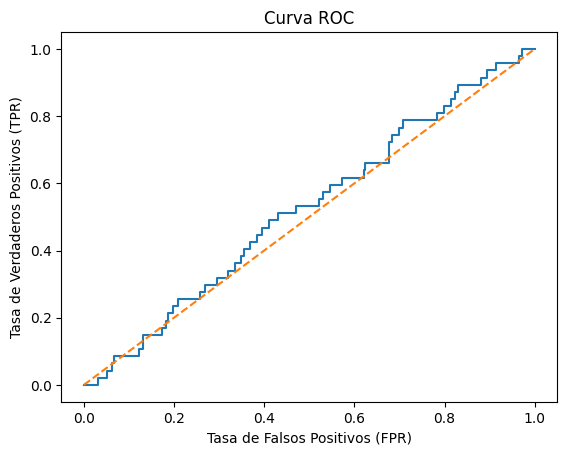

In [ ]:
# TRANSFORMADORES PERSONALIZADOS PARA FEATURES ESPECIALES

def antiguedad_desde_fecha(X):
    # Convierte fechas de alta a antigüedad en días desde la fecha de corte
    arr = np.asarray(X).ravel()
    fechas = pd.to_datetime(pd.Series(arr), errors="coerce")
    antiguedad = (fecha_corte - fechas.values).astype("timedelta64[D]").astype(float)
    if np.isnan(antiguedad).any():
        antiguedad = np.where(np.isnan(antiguedad), np.nanmean(antiguedad), antiguedad)
    return antiguedad.reshape(-1, 1)

def winsorizar_array_1_99(X):
    # Winsoriza al 1-99% por columna (numpy array)
    X = np.asarray(X, dtype=float).copy()
    for col in range(X.shape[1]):
        lo = np.nanpercentile(X[:, col], 1)
        hi = np.nanpercentile(X[:, col], 99)
        X[:, col] = np.clip(X[:, col], lo, hi)
    return X

# Transformadores de función
winsorizador_tf = FunctionTransformer(winsorizar_array_1_99, validate=False)
antiguedad_tf = FunctionTransformer(antiguedad_desde_fecha, validate=False)

# Definición de características por tipo
caracteristicas_numericas = ["edad", "ingreso"]
caracteristicas_categoricas = ["canal", "ciudad"]
caracteristica_fecha = ["fecha_alta"]

# Pipelines específicos por tipo
pipeline_numerico = Pipeline([
    ("imputador", SimpleImputer(strategy="median")),
    ("winsorizador", winsorizador_tf),
    ("escalador", StandardScaler()),
])

pipeline_categorico = Pipeline([
    ("imputador", SimpleImputer(strategy="most_frequent")),
    ("codificador", OneHotEncoder(handle_unknown="ignore", sparse_output=False)),
])

pipeline_fecha = Pipeline([
    ("antiguedad", antiguedad_tf),
    ("escalador", StandardScaler()),
])

# ColumnTransformer
preprocesador = ColumnTransformer([
    ("num",   pipeline_numerico,    caracteristicas_numericas),
    ("cat",   pipeline_categorico,  caracteristicas_categoricas),
    ("fecha", pipeline_fecha,       caracteristica_fecha),
])

# Aseguramos que las categóricas sean strings (no Categorical) para el imputador
X_train_pl = X_train.copy()
X_test_pl  = X_test.copy()
for col in caracteristicas_categoricas:
    X_train_pl[col] = X_train_pl[col].astype(object)
    X_test_pl[col]  = X_test_pl[col].astype(object)

# Pipeline completo: preprocesamiento + modelo
clasificador = Pipeline([
    ("preprocesamiento", preprocesador),
    ("modelo", LogisticRegression(max_iter=1000, class_weight="balanced")),
])

# Entrenamiento
clasificador.fit(X_train_pl, y_train)

# Predicciones y evaluación
y_predicciones = clasificador.predict(X_test_pl)
y_probabilidades = clasificador.predict_proba(X_test_pl)[:, 1]

print("ROC AUC:", round(roc_auc_score(y_test, y_probabilidades), 3))
print(classification_report(y_test, y_predicciones, digits=3))

# Curva ROC
fpr, tpr, umbrales = roc_curve(y_test, y_probabilidades)
plt.figure()
plt.plot(fpr, tpr)
plt.plot([0,1],[0,1], linestyle="--")
plt.xlabel("Tasa de Falsos Positivos (FPR)"); plt.ylabel("Tasa de Verdaderos Positivos (TPR)"); plt.title("Curva ROC")
plt.show()


### 4.6 (Opcional) SMOTE en el pipeline

**Ejercicio:**  
Investigar sobre la técnica SMOTE. Documentar en esta celda.

In [ ]:
try:
    from imblearn.over_sampling import SMOTE
    from imblearn.pipeline import Pipeline as ImbPipeline

    # Pipeline con SMOTE para balancear la clase minoritaria
    smote_clf = ImbPipeline(steps=[
        ("preprocesamiento", preprocesador),
        ("smote", SMOTE(random_state=42)),
        ("modelo", LogisticRegression(max_iter=1000)),
    ])

    smote_clf.fit(X_train_pl, y_train)

    pred_s = smote_clf.predict(X_test_pl)
    proba_s = smote_clf.predict_proba(X_test_pl)[:, 1]

    print("SMOTE - ROC AUC:", round(roc_auc_score(y_test, proba_s), 3))
    print(classification_report(y_test, pred_s, digits=3))

except Exception as e:
    print("SMOTE no disponible. Instala imbalanced-learn si deseas probarlo:", e)
    print("Comando de instalación: !pip install imbalanced-learn")


SMOTE - ROC AUC: 0.515
              precision    recall  f1-score   support

           0      0.852     0.455     0.593       253
           1      0.164     0.574     0.255        47

    accuracy                          0.473       300
   macro avg      0.508     0.515     0.424       300
weighted avg      0.744     0.473     0.540       300

